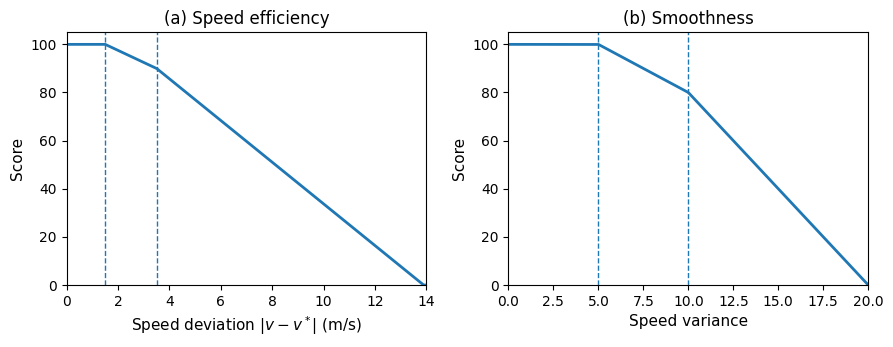

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plot settings
# -----------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# -----------------------------
# Speed efficiency score
# -----------------------------
speed_deviation = np.linspace(0, 14, 500)

speed_score = np.piecewise(
    speed_deviation,
    [
        speed_deviation <= 1.5,
        (speed_deviation > 1.5) & (speed_deviation <= 3.5),
        speed_deviation > 3.5,
    ],
    [
        100,
        lambda x: 100 - (x - 1.5) * 5,
        lambda x: np.maximum(0, 90 - (x - 3.5) * 8.662),
    ],
)

# -----------------------------
# Smoothness score
# -----------------------------
speed_variance = np.linspace(0, 20, 500)

smoothness_score = np.piecewise(
    speed_variance,
    [
        speed_variance <= 5,
        (speed_variance > 5) & (speed_variance <= 10),
        speed_variance > 10,
    ],
    [
        100,
        lambda x: 100 - (x - 5) * 4,
        lambda x: np.maximum(0, 80 - (x - 10) * 8),
    ],
)

# -----------------------------
# Draw figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

# (a) Speed efficiency
axes[0].plot(speed_deviation, speed_score, linewidth=2)

for x in [1.5, 3.5]:
    axes[0].axvline(x, linestyle="--", linewidth=1)

axes[0].set_xlim(0, 14)
axes[0].set_ylim(0, 105)
axes[0].set_xlabel(r"Speed deviation $|v-v^*|$ (m/s)")
axes[0].set_ylabel("Score")
axes[0].set_title("(a) Speed efficiency")

# (b) Smoothness
axes[1].plot(speed_variance, smoothness_score, linewidth=2)

for x in [5, 10]:
    axes[1].axvline(x, linestyle="--", linewidth=1)

axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 105)
axes[1].set_xlabel("Speed variance")
axes[1].set_ylabel("Score")
axes[1].set_title("(b) Smoothness")

plt.tight_layout()

plt.savefig(
    "driving_score_functions.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "driving_score_functions.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()